#### Random Forest Classifier

It is a kind of supervised machine learning technique that works with n number of decision trees so as to improve the accuracy and the performance of the model.

#### Aim of this Algorithm:--

1.  The main aim of this algorithm is to predict the species of the Iris plant using Random Forest Classifier and even predict the accuracy of the model.

2.  Then we can use hyper parameter tuning to improve the accuracy of the model.


#### Step 1: Import all the necessary libraries

In [1136]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets         import  load_iris
from    sklearn.model_selection  import  train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.ensemble         import  RandomForestClassifier
from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report

#### Step 2: Load the dataset

In [1137]:
#### Load the iris data

data = load_iris()

#### Construct the dataframe from the data

df = pd.DataFrame(data.data, columns= data.feature_names)


#### Adding the target to the dataframe
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### OBSERVATIONS:

1.  The above dataset explains about the details of the Iris Plant species.

2.  The independent feature are petal_length, petal_width, sepal_length, sepal_width.

3.  The dependent   feature is the target that determines the species of the Iris plant.

#### Step 3: Perform the Data Exploration

In [1138]:
#### get the first five rows of the dataset

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [1139]:
#### get the last five rows of the dataset

df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [1140]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 150


In [1141]:
#### Get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (150, 5)


In [1142]:
#### get the columns used in the dataset

df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [1143]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#### OBSERAVTIONS:

1.  All the independent features are floating in nature.

2.  The dependent feature ('target') is integer in nature.

In [1144]:
#### get the correlation between all the columns in the dataset

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

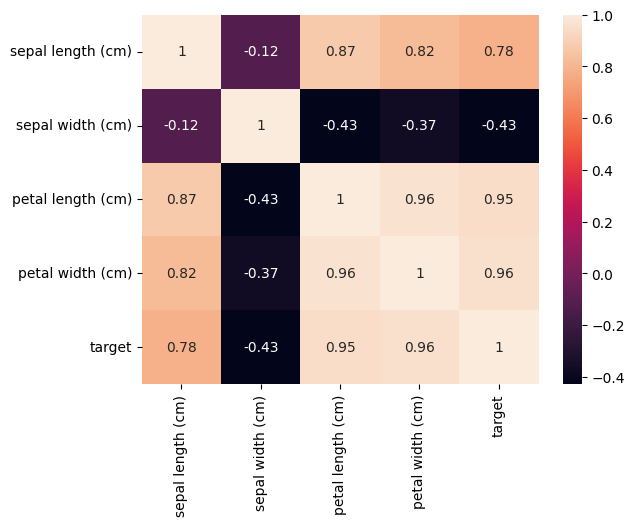

In [1145]:
#### get the graphical representation between all the numerical columns in the dataset

sns.heatmap(df.corr(), annot=True)

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1146]:
#### To check for the NULL records in the dataset

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1147]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


#### OBSERVATIONS:

1.  There is only one duplicate record in the dataset. So remove it.

In [1148]:
#### Remove the duplicate record from the dataset

df = df.drop_duplicates()

In [1149]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [1150]:
#### Rename the columns

df.rename(columns={"sepal length (cm)" : "sepal_length"    ,
                   "sepal width (cm)" : "sepal_width"      ,
                   "petal length (cm)" : "petal_length"    ,
                   "petal width (cm)"  :  "petal_width"}, inplace=True)

In [1151]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### OBSERVATIONS:

1.  Now all the columns have been renamed to their proper column names.

In [1152]:
#### Again check the length of the records in the dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 149


#### OBSERVATIONS:

1.  The length of the dataset has decreased from 150 to 149 as one duplicate record has been removed from the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [1153]:
#### independent features

X = df.drop(columns = 'target',axis=1)

print(X)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[149 rows x 4 columns]


In [1154]:
#### dependent features

Y = df['target']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 149, dtype: int64


#### Step 6: Divide the independent and dependent features into training and testing data

In [1155]:
from  sklearn.model_selection import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

In [1156]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
6,4.6,3.4,1.4,0.3
128,6.4,2.8,5.6,2.1
95,5.7,3.0,4.2,1.2
44,5.1,3.8,1.9,0.4
30,4.8,3.1,1.6,0.2
...,...,...,...,...
52,6.9,3.1,4.9,1.5
47,4.6,3.2,1.4,0.2
102,7.1,3.0,5.9,2.1
124,6.7,3.3,5.7,2.1


In [1157]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
69,5.6,2.5,3.9,1.1
66,5.6,3.0,4.5,1.5
141,6.9,3.1,5.1,2.3
7,5.0,3.4,1.5,0.2
147,6.5,3.0,5.2,2.0
57,4.9,2.4,3.3,1.0
84,5.4,3.0,4.5,1.5
28,5.2,3.4,1.4,0.2
138,6.0,3.0,4.8,1.8
127,6.1,3.0,4.9,1.8


In [1158]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (119, 4)
Shape of the input testing  data is: (30, 4)


In [1159]:
Y_train

6      0
128    2
95     1
44     0
30     0
      ..
52     1
47     0
102    2
124    2
16     0
Name: target, Length: 119, dtype: int64

In [1160]:
Y_test

69     1
66     1
141    2
7      0
147    2
57     1
84     1
28     0
138    2
127    2
20     0
42     0
18     0
93     1
140    2
22     0
77     1
14     0
107    2
38     0
63     1
134    2
41     0
10     0
96     1
51     1
104    2
116    2
132    2
56     1
Name: target, dtype: int64

In [1161]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (119,)
Shape of the output testing  data is: (30,)


#### Step 7: Perform Feature Scaling on the inputs

In [1162]:
from  sklearn.preprocessing import  StandardScaler

#### create an object for StanadrdScaler

sc = StandardScaler()

#### using the object for StandardScaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

print(X_train_scaled)

[[-1.50158712  0.7690314  -1.33909259 -1.17973677]
 [ 0.63982407 -0.58674247  1.04183404  1.1863645 ]
 [-0.19294695 -0.13481785  0.24819183  0.00331387]
 [-0.90675068  1.67288064 -1.05564894 -1.0482867 ]
 [-1.26365254  0.09114446 -1.22571513 -1.31118684]
 [-0.43088152 -1.49059172  0.02143691 -0.1281362 ]
 [ 0.63982407 -0.81270478  0.87176786  0.92346436]
 [ 0.52085678  0.54306908  1.26858896  1.71216479]
 [ 2.18639882 -0.58674247  1.66541007  1.05491443]
 [ 1.59156238 -0.13481785  1.1552115   0.52911415]
 [-0.19294695  3.02865451 -1.28240386 -1.0482867 ]
 [ 0.52085678 -0.36078016  1.04183404  0.79201429]
 [ 0.99672594  0.54306908  1.09852277  1.71216479]
 [ 0.52085678 -0.58674247  0.7583904   0.39766408]
 [-0.43088152  2.57672988 -1.33909259 -1.31118684]
 [ 0.87775865 -0.36078016  0.47494675  0.13476394]
 [-0.43088152 -1.26462941  0.13481437  0.13476394]
 [-0.78778339  2.35076757 -1.28240386 -1.44263691]
 [ 0.28292221 -0.58674247  0.13481437  0.13476394]
 [-1.14468525 -0.13481785 -1.33

In [1163]:
X_test_scaled = sc.transform(X_test)

print(X_test_scaled)

[[-0.31191424 -1.26462941  0.07812564 -0.1281362 ]
 [-0.31191424 -0.13481785  0.41825802  0.39766408]
 [ 1.23466052  0.09114446  0.7583904   1.44926464]
 [-1.02571797  0.7690314  -1.28240386 -1.31118684]
 [ 0.75879136 -0.13481785  0.81507913  1.05491443]
 [-1.14468525 -1.49059172 -0.26200673 -0.25958627]
 [-0.54984881 -0.13481785  0.41825802  0.39766408]
 [-0.78778339  0.7690314  -1.33909259 -1.31118684]
 [ 0.16395492 -0.13481785  0.58832421  0.79201429]
 [ 0.28292221 -0.13481785  0.64501294  0.79201429]
 [-0.54984881  0.7690314  -1.1690264  -1.31118684]
 [-1.7395217   0.31710677 -1.39578132 -1.31118684]
 [-0.19294695  1.67288064 -1.1690264  -1.17973677]
 [-1.02571797 -1.71655403 -0.26200673 -0.25958627]
 [ 0.99672594  0.09114446  1.04183404  1.58071472]
 [-1.50158712  1.22095602 -1.56584751 -1.31118684]
 [ 0.99672594 -0.13481785  0.70170167  0.66056422]
 [-0.07397966  2.12480526 -1.45247005 -1.31118684]
 [ 1.71052967 -0.36078016  1.43865515  0.79201429]
 [-1.7395217  -0.13481785 -1.39

#### OBSERVATIONS:

1.  All the inputs have been scaled in the same  range  starting from -1 to 1.

#### Step 8: Train the Random Forest Classifier Model

In [1164]:
from  sklearn.ensemble import RandomForestClassifier

#### create an object for RandomForestClassifier

ran = RandomForestClassifier(n_estimators=100,random_state=42)

#### using the object of RandomForestClassifier, train the model

ran.fit(X_train_scaled, Y_train)

RandomForestClassifier(random_state=42)

#### Step 9: Predict the model

In [1165]:
Y_pred = ran.predict(X_test_scaled)

In [1166]:
Y_pred

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

#### Step 10: Evaluate the Classification Metrics

In [1167]:
from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.33333333333333
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of the model for Iris Plant species dataset is 93.33

2.  As the accuracy of the model is high, so it is working fine.

#### Step 11: Perform Testing on the sample data

In [1168]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = ran.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[[-0.90675068  0.99499371 -1.33909259 -1.31118684]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1169]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = ran.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[[1.3536278  0.31710677 0.53163548 0.26621401]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1170]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = ran.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[[0.52085678 0.54306908 1.26858896 1.71216479]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 12: Visualizing Feature Importance

[0.11484225 0.02898517 0.41640472 0.43976786]
[3 2 0 1]
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')


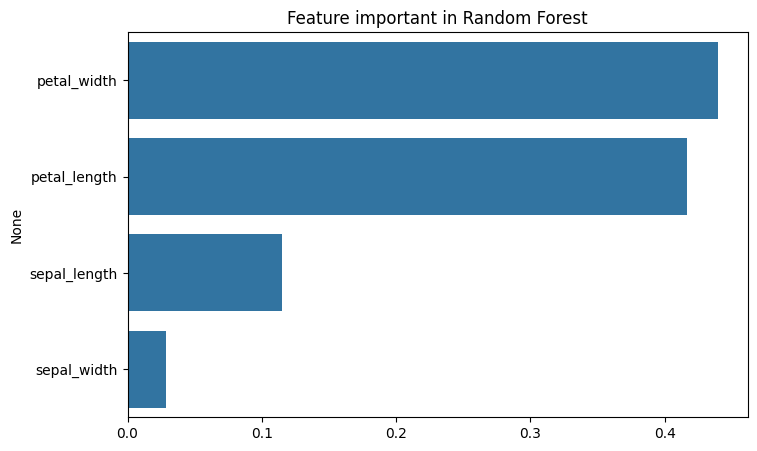

In [1171]:
#### extract all the important features from the dataset

features = ran.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()

#### OBSERVATIONS:

1. The above graph depicts about the list of all the features of the Iris Plant along with their importances.

2. petal_width is the feature in Iris plant dataset that is having the highest feature importance. So "petal_width" should be given the highest importance.

3. sepal_width is the feature in Iris plant dataset that is having the lowest feature importance. So "sepal_width" should be given the least importance.

#### Step 13: Perform Hyper Parameter Tuning using GridSearchCV

In [1172]:
#### define the pipeline

from  sklearn.pipeline    import  Pipeline

#### create the object for pipeline

pipeline = Pipeline([
    ("sc"   ,   StandardScaler())                ,
    ("ran"  ,   RandomForestClassifier(random_state=42))
])

In [1173]:
#### define the param grid

param_grid = {
    "ran__n_estimators"          :         [50, 100,    200]        ,
    "ran__max_depth"             :         [None,5,10,20]           ,
    "ran__min_samples_split"     :         [2,5,10]                 ,
    "ran__min_samples_leaf"      :         [1,2,4]                  ,
    "ran__criterion"             :         ["gini", "entropy"]
}

In [1174]:
#### perform the GridSearchCV

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

In [1175]:
#### Create the object for GridSearchCV

grid = GridSearchCV(
    pipeline                                                        ,
    param_grid           =          param_grid                      ,
    cv                   =             cv                           ,
    scoring              =          'accuracy'                      ,
    n_jobs               =             -1
)

In [1176]:
#### using the object of grid, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('ran',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'ran__criterion': ['gini', 'entropy'],
                         'ran__max_depth': [None, 5, 10, 20],
                         'ran__min_samples_leaf': [1, 2, 4],
                         'ran__min_samples_split': [2, 5, 10],
                         'ran__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [1177]:
#### Obtain the best parameters and the estimator of the model

best_parameter = grid.best_params_

print("Best Parametets of the model is:", best_parameter)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parametets of the model is: {'ran__criterion': 'gini', 'ran__max_depth': None, 'ran__min_samples_leaf': 1, 'ran__min_samples_split': 5, 'ran__n_estimators': 50}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('ran',
                 RandomForestClassifier(min_samples_split=5, n_estimators=50,
                                        random_state=42))])


In [1178]:
### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [1179]:
Y_pred_grid

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 2,
       0, 0, 1, 1, 2, 2, 2, 1])

In [1180]:
#### Evaluate the Classification Metrics

from        sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 96.66666666666667
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



#### OBSERVATIONS:

1.  The accuracy of the model has increased from 93.33  to 96.66 after performing hyper parameter tuning using GridSearchCV.

2.  The accuracy has improved for Random Forest Classifier using hyper parameter tuning with GridSearchcv.

#### Step 14: Predict the Species of the Iris Plant based on the sample data

In [1181]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1182]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1183]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 15: Visualizing the Feature Importances after performing Hyper Parameter Tuning

[0.11567071 0.01908211 0.42892863 0.43631855]
[3 2 0 1]
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')


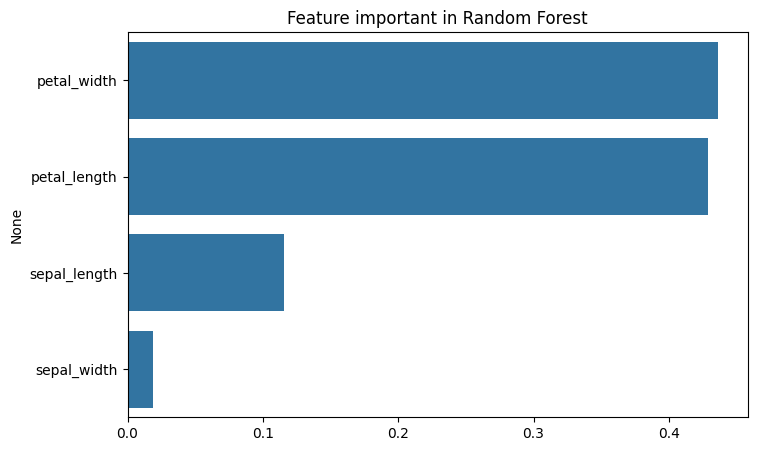

In [1184]:
#### extract all the important features from the dataset

ran_model = best_estimator.named_steps['ran']

features = ran_model.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()

#### OBSERVATIONS:

1. The above graph depicts about the list of all the features of the Iris Plant along with their importances.

2. petal_width is the feature in Iris plant dataset that is having the highest feature importance. So "petal_width" should be given the highest importance.

3. sepal_width is the feature in Iris plant dataset that is having the lowest feature importance. So "sepal_width" should be given the least importance.